In [223]:
# 1. Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

### Data Loading & Overview

In [224]:
# 2. Load Data
data = pd.read_csv("ect.csv")

In [225]:
# 3. Basic Info
print(data.shape)
print(data.info())
print(data.describe())

(74817, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74817 entries, 0 to 74816
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   UserID     74817 non-null  int64  
 1   SessionID  74817 non-null  int64  
 2   Timestamp  74817 non-null  object 
 3   EventType  74817 non-null  object 
 4   ProductID  32113 non-null  object 
 5   Amount     10682 non-null  float64
 6   Outcome    10682 non-null  object 
dtypes: float64(1), int64(2), object(4)
memory usage: 4.0+ MB
None
             UserID     SessionID        Amount
count  74817.000000  74817.000000  10682.000000
mean     500.740741      5.509777    253.189758
std      288.945183      2.869337    143.043974
min        1.000000      1.000000      5.131843
25%      251.000000      3.000000    130.933965
50%      501.000000      6.000000    253.112517
75%      751.000000      8.000000    378.832078
max     1000.000000     10.000000    499.981538


### Data Cleaning & Validation

In [226]:
# Convert Timestamp to datetime
data['Timestamp'] = pd.to_datetime(data['Timestamp'], errors='coerce')

In [227]:
# 5. Data Validation
print(data.isna().sum())

UserID           0
SessionID        0
Timestamp        0
EventType        0
ProductID    42704
Amount       64135
Outcome      64135
dtype: int64


In [228]:
# 6. Unique Values
print(data['EventType'].unique())

['page_view' 'product_view' 'add_to_cart' 'login' 'click' 'logout'
 'purchase']


### Event Analysis

In [229]:
# 7. Filter Product Events
product_events = data[data['EventType'].isin(['product_view','add_to_cart','purchase'])]
print("Missing ProductID:", product_events['ProductID'].isna().sum())

Missing ProductID: 0


In [230]:
# 8. Purchase Validation
purchase_events = data[data['EventType'] == 'purchase']
print(purchase_events[['Amount','Outcome']].isna().sum())

Amount     0
Outcome    0
dtype: int64


In [231]:
# 9. Key Metrics
print("Total Users:", data['UserID'].nunique())
print("Total Products:", data['ProductID'].nunique())
print("Total Purchases:", data[data['EventType']=='purchase'].shape[0])

Total Users: 1000
Total Products: 8747
Total Purchases: 10682


In [232]:
# 10. Event Distribution
event_counts = data['EventType'].value_counts()
print(event_counts)

EventType
page_view       10819
add_to_cart     10735
product_view    10696
logout          10685
purchase        10682
click           10632
login           10568
Name: count, dtype: int64


### Sessionization

In [233]:
# Sort data
data = data.sort_values(['UserID', 'Timestamp'])

In [234]:
# Time difference between events
data['time_diff'] = data.groupby('UserID')['Timestamp'].diff()

In [235]:
# Define new session (45 min gap)
data['new_session'] = (data['time_diff'] > pd.Timedelta(minutes=45)) | (data['time_diff'].isna())
data['new_session'].value_counts()

new_session
True     73978
False      839
Name: count, dtype: int64

In [236]:
# Create session ID
data['session_id'] = data.groupby('UserID')['new_session'].cumsum()

### Session Analysis

In [237]:
# Sessions per user
sessions_per_user = data.groupby('UserID')['session_id'].nunique()
print(sessions_per_user.describe())

count    1000.00000
mean       73.97800
std         5.38261
min        58.00000
25%        70.00000
50%        74.00000
75%        78.00000
max        93.00000
Name: session_id, dtype: float64


In [238]:
# Session size
session_size = data.groupby(['UserID','session_id']).size()

In [239]:
# Event Distribution per Session
session_events = data.groupby(['session_id','EventType']).size().unstack(fill_value=0)
session_events.describe()

EventType,add_to_cart,click,login,logout,page_view,product_view,purchase
count,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000
mean,115.430108,114.322581,113.634409,114.892473,116.333333,115.010753,114.860215
std,53.109075,54.001240,52.411786,53.090051,53.944684,52.686417,54.154287
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,109.000000,95.000000,102.000000,112.000000,114.000000,113.000000,118.000000
50%,138.000000,138.000000,135.000000,137.000000,140.000000,139.000000,138.000000
75%,148.000000,150.000000,147.000000,148.000000,148.000000,148.000000,149.000000
max,167.000000,171.000000,178.000000,172.000000,166.000000,170.000000,174.000000


In [240]:
# Purchase Sessions
purchase_sessions = data[data['EventType'] == 'purchase']
total_purchase_sessions = purchase_sessions.groupby(['UserID','session_id']).size().count()
print("Total Purchase Sessions:", total_purchase_sessions)

Total Purchase Sessions: 10666


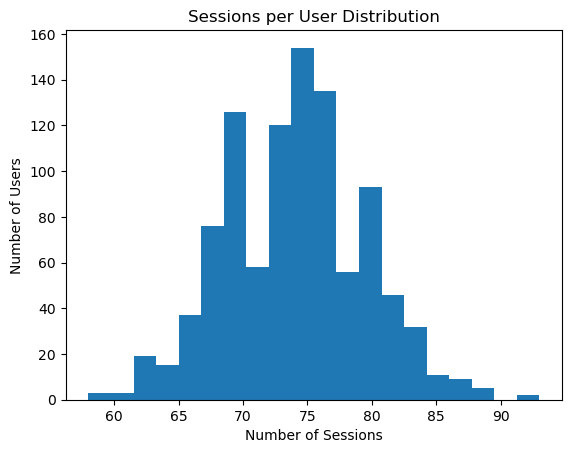

In [241]:
sessions_per_user.plot(kind='hist', bins=20)

plt.title('Sessions per User Distribution')
plt.xlabel('Number of Sessions')
plt.ylabel('Number of Users')

plt.show()

### Session Analysis Insights

Average sessions per user ≈ 74.  
Sessions contain a high number of events, indicating sustained and continuous user interaction rather than short, single-action visits.  
This suggests that users are highly engaged with the platform during each session.

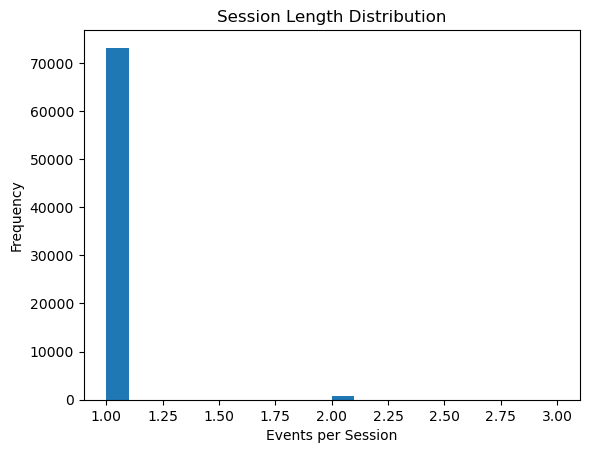

In [242]:
# Session size (number of events per session)
session_size = data.groupby(['UserID','session_id']).size()
session_size.plot(kind='hist', bins=20)

plt.title('Session Length Distribution')
plt.xlabel('Events per Session')
plt.ylabel('Frequency')

plt.show()

In [243]:
purchase_sessions = data[data['EventType']=='purchase'].groupby(['UserID','session_id']).size()
total_sessions = data.groupby(['UserID','session_id']).size()
len_total_sessions=len(total_sessions)
print(f"Total Sessions: {(len_total_sessions)}\nSessions with Purchase:{len(purchase_sessions)}")

Total Sessions: 73978
Sessions with Purchase:10666


In [244]:
data_copy=data.copy()
data_copy['is_product_view'] = data_copy['EventType'].isin(['product_view','page_view']).astype(int)
data_copy['is_cart'] = (data_copy['EventType'] == 'add_to_cart').astype(int)
data_copy['is_purchase'] = (data_copy['EventType'] == 'purchase').astype(int)
session_df = data_copy.groupby(['UserID', 'session_id']).agg(
    events_count=('EventType', 'count'),
    product_views=('is_product_view', 'sum'),
    carts=('is_cart', 'sum'),
    purchases=('is_purchase', 'sum'),
    session_start=('Timestamp', 'min'),
    session_end=('Timestamp', 'max')
).reset_index()
session_df

,UserID,session_id,events_count,product_views,carts,purchases,session_start,session_end
0,1,1,1,1,0,0,2024-01-01 23:09:51,2024-01-01 23:09:51
1,1,2,1,0,1,0,2024-01-02 00:15:51,2024-01-02 00:15:51
2,1,3,1,0,0,0,2024-01-03 23:51:05,2024-01-03 23:51:05
3,1,4,1,0,1,0,2024-01-04 09:25:49,2024-01-04 09:25:49
4,1,5,1,0,0,0,2024-01-04 17:09:29,2024-01-04 17:09:29
...,...,...,...,...,...,...,...,...
73973,1000,78,1,1,0,0,2024-07-10 09:34:52,2024-07-10 09:34:52
73974,1000,79,1,0,0,0,2024-07-11 12:40:44,2024-07-11 12:40:44
73975,1000,80,1,0,1,0,2024-07-13 15:30:59,2024-07-13 15:30:59
73976,1000,81,1,0,0,0,2024-07-15 08:49:32,2024-07-15 08:49:32


In [245]:
# Check sessions where start == end
same_time = session_df[session_df['session_start'] == session_df['session_end']]
same_time[['UserID', 'session_id', 'events_count', 'session_start', 'session_end']].head()

,UserID,session_id,events_count,session_start,session_end
0,1,1,1,2024-01-01 23:09:51,2024-01-01 23:09:51
1,1,2,1,2024-01-02 00:15:51,2024-01-02 00:15:51
2,1,3,1,2024-01-03 23:51:05,2024-01-03 23:51:05
3,1,4,1,2024-01-04 09:25:49,2024-01-04 09:25:49
4,1,5,1,2024-01-04 17:09:29,2024-01-04 17:09:29


In [246]:
#How many products receive the most user interactions (views/clicks), and which are the top ones
product_event = data[data['EventType'].isin(['product_view','add_to_cart','purchase'])]

product_stats = (
    product_event
    .groupby(['ProductID', 'EventType'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# Rename columns (important)
product_stats = product_stats.rename(columns={
    'product_view': 'views',
    'add_to_cart': 'carts',
    'purchase': 'purchases'
})

# Total interactions
product_stats['total_interactions'] = (
    product_stats['views'] +
    product_stats['carts'] +
    product_stats['purchases']
)

product_stats=product_stats.sort_values('total_interactions', ascending=False)
product_stats.head()

EventType,ProductID,carts,views,purchases,total_interactions
3615,prod_4714,3,6,3,12
4918,prod_6051,6,5,1,12
6746,prod_7938,2,6,3,11
129,prod_1131,3,3,5,11
4464,prod_5583,4,3,4,11


#### Create session-level flags for funnel stages (view, cart, purchase)

In [247]:
#Conversion Funnel: view → add_to_cart → purchase
funnel_events=data[data['EventType'].isin(['product_view','add_to_cart','purchase'])].copy()
funnel_events = funnel_events.sort_values(['UserID','session_id'])
funnel_events['EventType'].value_counts()

EventType
add_to_cart     10735
product_view    10696
purchase        10682
Name: count, dtype: int64

In [248]:
funnel_sessions = (
    funnel_events
    .assign(
        has_view = (funnel_events['EventType'] == 'product_view').astype(int),
        has_cart = (funnel_events['EventType'] == 'add_to_cart').astype(int),
        has_purchase = (funnel_events['EventType'] == 'purchase').astype(int)
    )
    .groupby('session_id')[['has_view','has_cart','has_purchase']]
    .max()
    .reset_index()
)

In [249]:
funnel_sessions.shape

(89, 4)

In [250]:
funnel_sessions[['has_view','has_cart','has_purchase']].sum()

has_view        86
has_cart        89
has_purchase    87
dtype: int64

In [251]:
view_sessions = funnel_sessions['has_view'].sum()

cart_sessions = (
    (funnel_sessions['has_view'] == 1) &
    (funnel_sessions['has_cart'] == 1)
).sum()

purchase_sessions = (
    (funnel_sessions['has_view'] == 1) &
    (funnel_sessions['has_cart'] == 1) &
    (funnel_sessions['has_purchase'] == 1)
).sum()

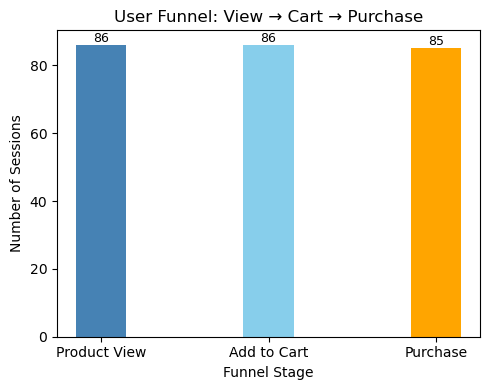

In [252]:
stages = ['Product View', 'Add to Cart', 'Purchase']
values = [view_sessions, cart_sessions, purchase_sessions]

plt.figure(figsize=(5,4))
bars = plt.bar(stages, values, color=['steelblue', 'skyblue', 'orange'], width=0.3)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{int(height)}', ha='center', va='bottom', fontsize=9)

plt.title('User Funnel: View → Cart → Purchase')
plt.ylabel('Number of Sessions')
plt.xlabel('Funnel Stage')
plt.tight_layout()
plt.show()

In [253]:
print(f"""
view_sessions: {view_sessions}
cart_sessions: {cart_sessions}
purchase_sessions: {purchase_sessions}
""")


view_sessions: 86
cart_sessions: 86
purchase_sessions: 85



In [254]:
view_to_cart = cart_sessions / view_sessions if view_sessions else 0
cart_to_purchase = purchase_sessions / cart_sessions if cart_sessions else 0
view_to_purchase = purchase_sessions / view_sessions if view_sessions else 0

In [255]:
print(f"""
view_to_cart: {view_to_cart:.2f}
cart_to_purchase: {cart_to_purchase:.2f}
view_to_purchase: {view_to_purchase:.2f}
""")


view_to_cart: 1.00
cart_to_purchase: 0.99
view_to_purchase: 0.99



Note on Dataset:

The dataset shows unusually high funnel completion rates, which are uncommon in real-world e-commerce scenarios. This suggests that the data may be simulated or simplified, and therefore, insights are interpreted with this limitation in mind.

#### Which products contribute most to revenue?

In [256]:
data1=data[data['EventType']=='purchase']
revenue_event=data1[['ProductID','Timestamp','Amount']].copy()

In [257]:
prod_revenue = (
    revenue_event
    .groupby('ProductID', as_index=False)['Amount']
    .sum()
    .rename(columns={'Amount': 'Total_revenue'})
    .sort_values('Total_revenue', ascending=False)
)
prod_revenue.head()

,ProductID,Total_revenue
6087,prod_9747,2163.821351
239,prod_1342,2141.778215
2283,prod_4270,1970.578638
2164,prod_4114,1960.632916
3429,prod_5908,1948.375514


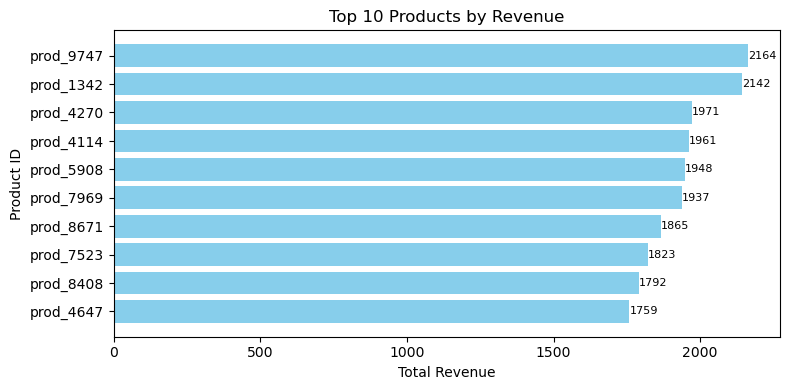

In [258]:
top_n = 10  # or 15
top_prod = prod_revenue.nlargest(top_n, 'Total_revenue')

plt.figure(figsize=(8, 4))
plt.barh(top_prod['ProductID'], top_prod['Total_revenue'], color='skyblue')
plt.gca().invert_yaxis()  # biggest on top

for i, v in enumerate(top_prod['Total_revenue']):
    plt.text(v, i, f'{v:.0f}', va='center', ha='left', fontsize=8)

plt.title(f'Top {top_n} Products by Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Product ID')
plt.tight_layout()
plt.show()

#### How does revenue change over time based on purchase events

In [259]:
revenue_event['Quarter'] = revenue_event['Timestamp'].dt.to_period('Q')
revenue_event['Month'] = revenue_event['Timestamp'].dt.month
revenue_event

,ProductID,Timestamp,Amount,Quarter,Month
34,prod_6690,2024-01-19 16:51:29,149.270047,2024Q1,1
42,prod_2362,2024-02-17 19:31:30,35.606156,2024Q1,2
15,prod_5244,2024-03-15 05:22:41,72.913619,2024Q1,3
73,prod_3149,2024-03-16 05:05:39,457.627967,2024Q1,3
41,prod_5113,2024-04-10 13:43:05,454.105277,2024Q2,4
...,...,...,...,...,...
74788,prod_8329,2024-04-24 13:23:55,86.339139,2024Q2,4
74815,prod_2515,2024-04-30 16:19:48,198.757849,2024Q2,4
74780,prod_8884,2024-05-08 09:40:35,201.858421,2024Q2,5
74812,prod_1238,2024-05-11 22:48:45,186.208225,2024Q2,5


In [260]:
revenue_change = (
    revenue_event
    .groupby(['Quarter', 'Month'], as_index=False)['Amount']
    .sum()
    .rename(columns={'Amount': 'Total_revenue'})
    .sort_values(['Quarter', 'Month'])
)
revenue_change

,Quarter,Month,Total_revenue
0,2024Q1,1,402125.529561
1,2024Q1,2,376519.999303
2,2024Q1,3,394057.928814
3,2024Q2,4,408235.696661
4,2024Q2,5,426323.724682
5,2024Q2,6,402153.223718
6,2024Q3,7,295156.896709


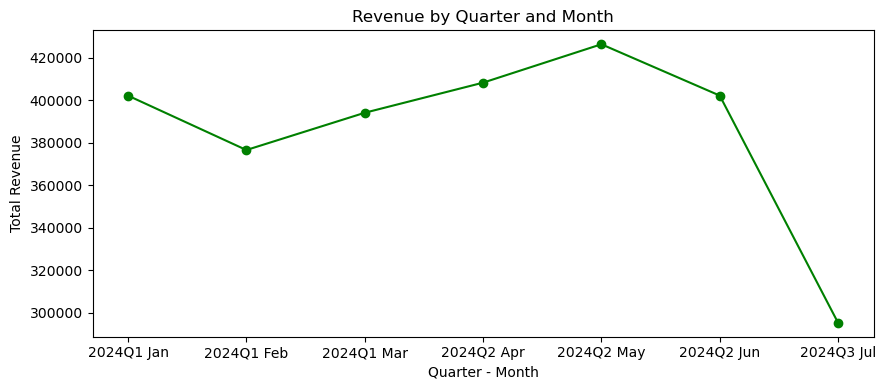

In [261]:
import calendar

revenue_change['MonthName'] = revenue_change['Month'].apply(lambda m: calendar.month_abbr[int(m)])

revenue_change['Label'] = (
    revenue_change['Quarter'].astype(str) + ' ' + revenue_change['MonthName']
)

plt.figure(figsize=(9, 4))
plt.plot(revenue_change['Label'], revenue_change['Total_revenue'],
         marker='o', color='green')

plt.title('Revenue by Quarter and Month')
plt.xlabel('Quarter - Month')
plt.ylabel('Total Revenue')
plt.tight_layout()
plt.show()

#### Which products have high views but low purchases

In [263]:
product_events=data[['ProductID','EventType']].copy()
product_events=product_events[product_events['EventType'].isin(['product_view','purchase'])]
counts = (
    product_events
    .groupby(['ProductID', 'EventType'])
    .size()                            # counts rows per (ProductID, EventType)
    .unstack(fill_value=0)             # columns: 'product_view', 'purchase'
    .reset_index()
)
counts

EventType,ProductID,product_view,purchase
0,prod_1001,1,1
1,prod_1002,1,0
2,prod_1004,1,0
3,prod_1005,2,0
4,prod_1006,1,1
...,...,...,...
8187,prod_9994,3,3
8188,prod_9995,2,1
8189,prod_9997,2,0
8190,prod_9998,0,2


In [264]:
# Clean data
counts = counts.rename(columns={
    'product_view': 'view_count',
    'purchase': 'purchase_count'
})

counts = counts[counts['view_count'] > 0]

counts['conversion_rate'] = counts['purchase_count'] / counts['view_count']
weighted_conversion = counts['purchase_count'].sum() / counts['view_count'].sum()
counts.sort_values('conversion_rate',ascending=False)

EventType,ProductID,view_count,purchase_count,conversion_rate
2973,prod_4270,1,7,7.0
6501,prod_8136,1,7,7.0
7982,prod_9769,1,6,6.0
2726,prod_3995,1,6,6.0
6106,prod_7704,1,6,6.0
...,...,...,...,...
5983,prod_7569,1,0,0.0
5982,prod_7568,1,0,0.0
2780,prod_4060,2,0,0.0
2784,prod_4064,2,0,0.0


In some cases, purchase counts exceed product views due to the dataset structure, 
where events are not strictly sequential or session-bound. 
As a result, product-level conversion rates may exceed 100% and should be interpreted with caution.

#### Identify products with high user interest but low conversion (optimization opportunities)

In [265]:
# Insight: High views, low purchases
high_view_low_purchase = counts.sort_values(
    by=['view_count', 'purchase_count'],
    ascending=[False, True]
).head(10)

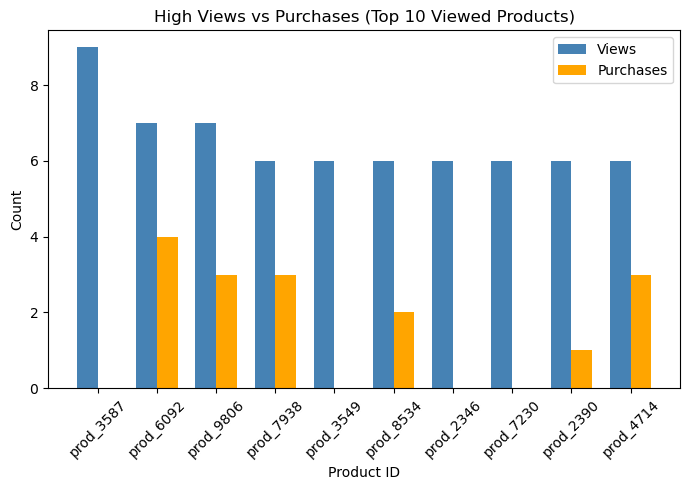

In [266]:
# pick top N products by views
top_n = 10
top_view = counts.sort_values('view_count', ascending=False).head(top_n)

x = range(len(top_view))
width = 0.35

plt.figure(figsize=(7, 5))
plt.bar([i - width/2 for i in x], top_view['view_count'], 
        width=width, label='Views', color='steelblue')
plt.bar([i + width/2 for i in x], top_view['purchase_count'], 
        width=width, label='Purchases', color='orange')

plt.xticks(x, top_view['ProductID'])
plt.title(f'High Views vs Purchases (Top {top_n} Viewed Products)')
plt.xlabel('Product ID')
plt.ylabel('Count')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Products with best conversion rate

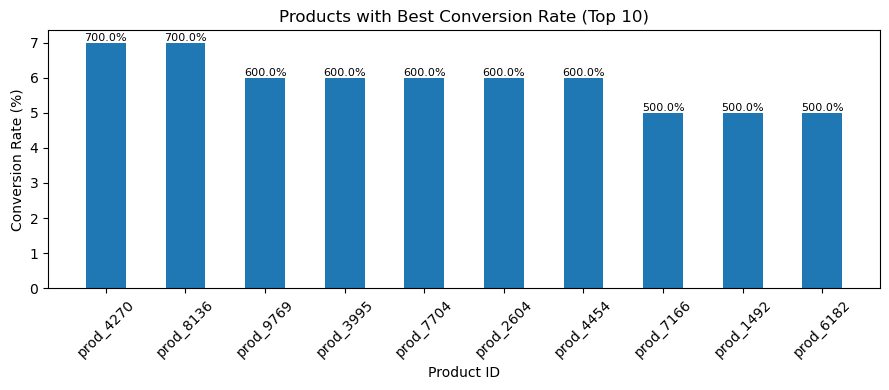

In [267]:
top_n = 10

# Step 1: Select top N products
top_products = counts.sort_values(
    'conversion_rate', ascending=False
).head(top_n)

# Step 2: Plot
plt.figure(figsize=(9, 4))
plt.bar(top_products['ProductID'], top_products['conversion_rate'], width=0.5 )

# Step 3: Add labels
for x, v in zip(top_products['ProductID'], top_products['conversion_rate']):
    plt.text(x, v, f'{v*100:.1f}%', ha='center', va='bottom', fontsize=8)

plt.title(f'Products with Best Conversion Rate (Top {top_n})')
plt.xlabel('Product ID')
plt.ylabel('Conversion Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### User interaction on plaform with repeat users and purchase count

##### How do users behave on the platform?

In [268]:
behavior=data[['UserID','session_id','EventType','Timestamp']].copy()
event_dist = (
    behavior
    .groupby('EventType')       #Count events per EventType (distribution of actions)
    .size()
    .reset_index(name='event_count')
)
event_dist['percentage'] = (
    event_dist['event_count'] / event_dist['event_count'].sum()
) * 100
event_dist = event_dist.sort_values('percentage', ascending=False)

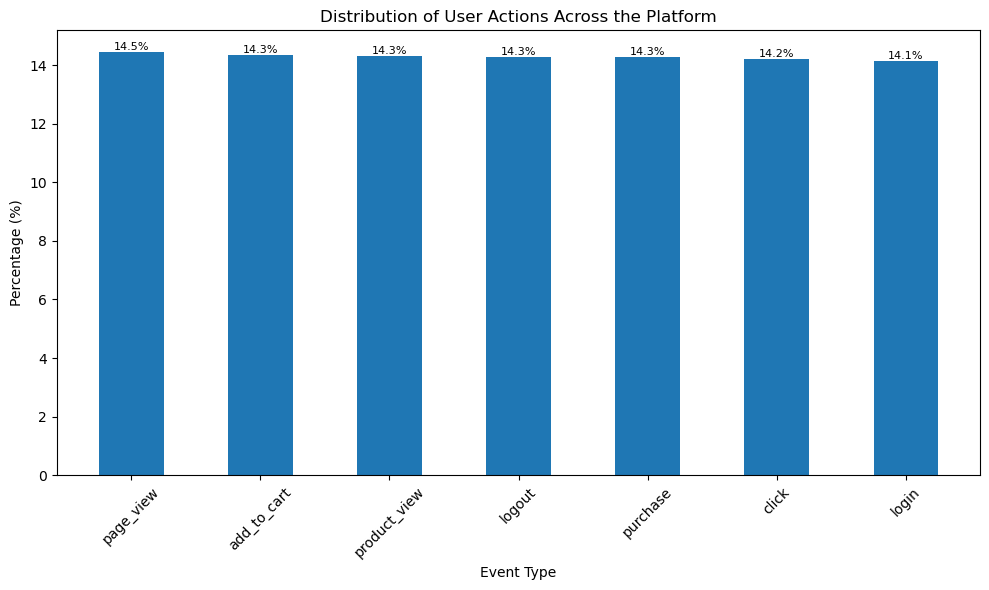

In [269]:
plt.figure(figsize=(10,6))

plt.bar(event_dist['EventType'], event_dist['percentage'], width=0.5)

# Annotate with percentage (correct scale)
for i, v in zip(event_dist['EventType'], event_dist['percentage']):
    plt.text(i, v, f'{v:.1f}%', ha='center', va='bottom', fontsize=8)

plt.title('Distribution of User Actions Across the Platform')  # fixed extra ')'
plt.xlabel('Event Type')
plt.ylabel('Percentage (%)')

plt.xticks(rotation=45)

# Give more space instead of relying only on tight_layout
plt.subplots_adjust(bottom=0.25)

plt.tight_layout()
plt.show()

User activity is relatively balanced across different event types, 
indicating consistent engagement across browsing, interaction, and transaction stages. 
However, purchase events are nearly equal to product views, suggesting unusually high conversion behavior in the dataset.

In [270]:
user_interaction = (
    behavior
    .groupby(['UserID','EventType'])   # user interaction with the platform through events
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

order = [
    'login',
    'page_view',
    'click',
    'product_view',
    'add_to_cart',
    'purchase',
    'logout'
]

user_interaction = user_interaction[['UserID'] + order]
user_interaction

EventType,UserID,login,page_view,click,product_view,add_to_cart,purchase,logout
0,1,11,15,5,14,23,8,6
1,2,9,10,10,4,18,13,9
2,3,5,9,10,10,11,6,13
3,4,13,17,9,9,14,9,12
4,5,8,14,15,14,13,7,13
...,...,...,...,...,...,...,...,...
995,996,8,12,12,12,10,12,9
996,997,12,14,12,15,7,7,11
997,998,5,11,10,17,13,6,10
998,999,13,10,11,9,9,12,11


In [271]:
session_behavior=(
    behavior
    .groupby(['session_id','EventType'])   #Summarizes how often each event type occurs within each session
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
order = [
    'login',
    'page_view',
    'click',
    'product_view',
    'add_to_cart',
    'purchase',
    'logout'
]

session_behavior = session_behavior[['session_id'] + order]
print(session_behavior.describe())
session_behavior

EventType  session_id       login   page_view       click  product_view  \
count       93.000000   93.000000   93.000000   93.000000     93.000000   
mean        47.000000  113.634409  116.333333  114.322581    115.010753   
std         26.990739   52.411786   53.944684   54.001240     52.686417   
min          1.000000    0.000000    0.000000    0.000000      0.000000   
25%         24.000000  102.000000  114.000000   95.000000    113.000000   
50%         47.000000  135.000000  140.000000  138.000000    139.000000   
75%         70.000000  147.000000  148.000000  150.000000    148.000000   
max         93.000000  178.000000  166.000000  171.000000    170.000000   

EventType  add_to_cart    purchase      logout  
count        93.000000   93.000000   93.000000  
mean        115.430108  114.860215  114.892473  
std          53.109075   54.154287   53.090051  
min           0.000000    0.000000    0.000000  
25%         109.000000  118.000000  112.000000  
50%         138.000000  138.00

EventType,session_id,login,page_view,click,product_view,add_to_cart,purchase,logout
0,1,163,148,145,151,130,128,145
1,2,149,138,137,150,150,133,154
2,3,154,143,122,136,155,145,158
3,4,148,144,154,142,137,138,146
4,5,142,158,126,150,157,153,126
...,...,...,...,...,...,...,...,...
88,89,0,1,1,0,2,0,0
89,90,0,0,1,0,0,0,1
90,91,1,0,1,0,0,0,0
91,92,1,1,0,0,0,0,0


In [272]:
repeats = data[['UserID', 'session_id']].copy()

# Count how many sessions each user has
user_sessions = (
    repeats
    .drop_duplicates(['UserID', 'session_id'])  # one row per user-session
    .groupby('UserID')
    .size()
    .reset_index(name='session_count')
)

# How many repeat users (more than 1 session)
repeat_users_count= (user_sessions['session_count'] > 1).sum()
print(user_sessions.head())
print(repeat_users_count)

   UserID  session_count
0       1             82
1       2             73
2       3             64
3       4             83
4       5             84
1000


In [273]:
# 1. Find purchase sessions
purchase_sessions = (
    data.loc[data['EventType'] == 'purchase', 'session_id']
    .unique()
)
display(purchase_sessions)
# 2. Filter all events to only those sessions
purchase_session_events = data[data['session_id'].isin(purchase_sessions)]
display(purchase_session_events)
# 3. Count actions within purchase sessions
actions_in_purchase_sessions = (
    purchase_session_events
    .groupby('EventType')
    .size()
    .reset_index(name='event_counts')
)
print(actions_in_purchase_sessions)

array([10, 22, 34, 35, 51, 69, 75, 78,  4,  7, 14, 16, 18, 27, 38, 41, 54,
       57, 62, 65,  5, 25, 28, 45, 55, 58, 19, 73, 81, 23, 56, 70, 15, 17,
       24, 29, 40, 63, 68, 71,  1, 13, 26, 30, 36, 49, 53, 60, 64,  2,  6,
       12, 31, 33, 37, 21, 50, 74, 77,  8, 32, 39, 44, 46, 47, 43, 80,  9,
       52, 42, 61, 67, 76, 82,  3, 20, 48, 11, 59, 72, 66, 79, 83, 84, 85,
       88, 87])

,UserID,SessionID,Timestamp,EventType,ProductID,Amount,Outcome,time_diff,new_session,session_id
5,1,1,2024-01-01 23:09:51,page_view,NaN,NaN,NaN,NaT,True,1
32,1,4,2024-01-02 00:15:51,add_to_cart,prod_6144,NaN,NaN,0 days 01:06:00,True,2
36,1,5,2024-01-03 23:51:05,logout,NaN,NaN,NaN,1 days 23:35:14,True,3
29,1,4,2024-01-04 09:25:49,add_to_cart,prod_1102,NaN,NaN,0 days 09:34:44,True,4
65,1,8,2024-01-04 17:09:29,click,NaN,NaN,NaN,0 days 07:43:40,True,5
...,...,...,...,...,...,...,...,...,...,...
74752,1000,3,2024-07-10 09:34:52,product_view,prod_7884,NaN,NaN,5 days 15:10:53,True,78
74748,1000,2,2024-07-11 12:40:44,logout,NaN,NaN,NaN,1 days 03:05:52,True,79
74810,1000,10,2024-07-13 15:30:59,add_to_cart,prod_1899,NaN,NaN,2 days 02:50:15,True,80
74794,1000,8,2024-07-15 08:49:32,click,NaN,NaN,NaN,1 days 17:18:33,True,81


      EventType  event_counts
0   add_to_cart         10729
1         click         10628
2         login         10562
3        logout         10682
4     page_view         10813
5  product_view         10694
6      purchase         10682


In [274]:
"""Purchase sessions are strongly associated with product interaction behaviors such as product views and add-to-cart actions. 
This suggests that user engagement with product pages is a key driver of conversions."""

'Purchase sessions are strongly associated with product interaction behaviors such as product views and add-to-cart actions. \nThis suggests that user engagement with product pages is a key driver of conversions.'

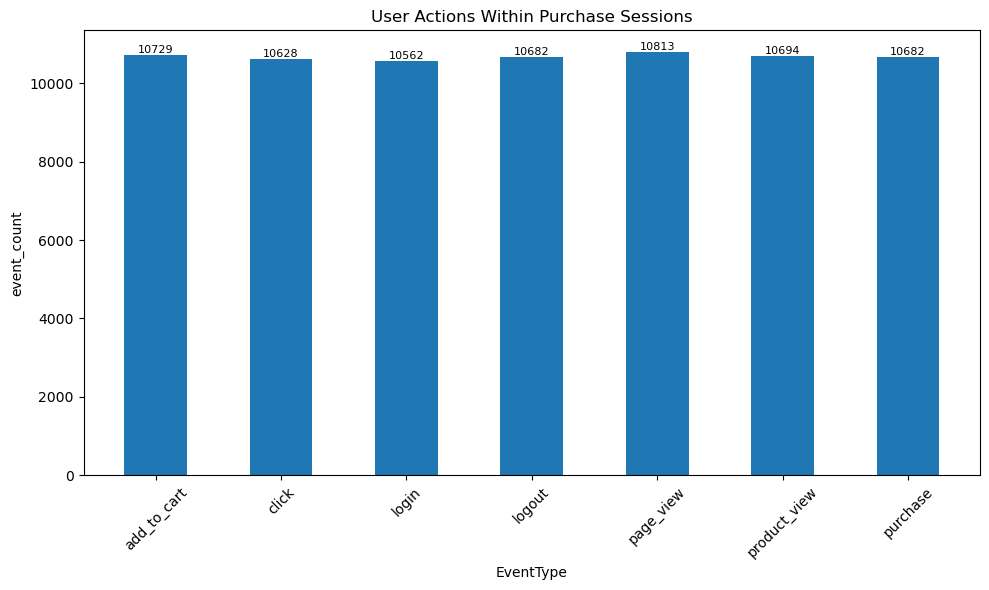

In [275]:
plt.figure(figsize=(10,6))
plt.bar(actions_in_purchase_sessions['EventType'],actions_in_purchase_sessions['event_counts'],width=0.5)
for i,v in zip(actions_in_purchase_sessions['EventType'],actions_in_purchase_sessions['event_counts']):
    plt.text(i, v,f'{v}', ha='center', va='bottom', fontsize=8)
plt.title('User Actions Within Purchase Sessions')
plt.xlabel('EventType')
plt.ylabel('event_count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

All users in the dataset have multiple sessions, indicating strong user retention and repeat engagement on the platform.